 ## MSN 514 HW:12

 ### Erinç Ada Ceylan 22101844

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import sympy as sp


 ### 1) Define the system

In [3]:
def f(t, v, A=1.0, B=2.5, q=0.5):
    x, y = v
    d = 1 + q*x**2
    return [B - x - x*y/d,
            A - x*y/d]


 ### 2) Fixed points

In [4]:
def find_fp(A, B, q):
    fps = []
    # interior: x = B - A
    x1 = B - A
    if x1 > 0:
        y1 = A*(1 + q*x1**2)/x1
        if np.allclose(f(0, [x1, y1], A, B, q), [0, 0], atol=1e-8):
            fps.append((x1, y1))
    # trivial: A=0 ⇒ (0,0)
    if abs(A) < 1e-8:
        fps.append((0.0, 0.0))
    return fps


 ### 3) Jacobian, trace & det

In [5]:
x, y, A_s, B_s, q_s = sp.symbols('x y A B q', real=True, positive=True)
d = 1 + q_s*x**2
dx = B_s - x - x*y/d
dy = A_s - x*y/d
J = sp.Matrix([dx, dy]).jacobian([x, y])
tr_expr = sp.simplify(J.trace())
det_expr = sp.simplify(J.det())
tr_f = sp.lambdify((x, y, A_s, B_s, q_s), tr_expr, 'numpy')
det_f = sp.lambdify((x, y, A_s, B_s, q_s), det_expr, 'numpy')

def classify(fp, A, B, q):
    x0, y0 = fp
    tr0 = tr_f(x0, y0, A, B, q)
    dt0 = det_f(x0, y0, A, B, q)
    if dt0 < 0:
        return 'saddle'
    if tr0 < 0:
        return 'stable node/focus'
    if tr0 > 0:
        return 'unstable node/focus'
    return 'Hopf point'


 ### 4) Nullclines

In [6]:
def plot_null(A, B, q):
    X = np.linspace(0.01, B+2, 400)
    Yx = (B - X)*(1 + q*X**2)/X   # dx/dt=0
    Yy = A*(1 + q*X**2)/X         # dy/dt=0
    plt.plot(X, Yx, 'r', label='dx/dt=0')
    plt.plot(X, Yy, 'b', label='dy/dt=0')
    for fp in find_fp(A, B, q):
        plt.plot(*fp, 'ko')
    plt.xlabel('x'); plt.ylabel('y')
    plt.title(f'Nullclines (A={A}, B={B}, q={q})')
    plt.legend(); plt.grid(); plt.show()


 ### 5) Hopf bifurcation curve

In [7]:
def hopf_curve(q, Bmin=0.1, Bmax=5, n=200):
    Bv = np.linspace(Bmin, Bmax, n)
    Ac = []
    for B in Bv:
        def eq(A):
            x1 = B - A
            y1 = A*(1 + q*x1**2)/x1
            return tr_f(x1, y1, A, B, q)
        try:
            A0 = min(B*0.5, 1.0)
            A_star = fsolve(eq, A0)[0]
        except:
            A_star = np.nan
        Ac.append(A_star if 0 < A_star < B else np.nan)
    plt.plot(Bv, Ac, 'k')
    plt.xlabel('B'); plt.ylabel('A_c')
    plt.title('Hopf bifurcation curve'); plt.grid(); plt.show()


 ### 6) Phase portrait

In [8]:
def plot_phase(A, B, q):
    xs = np.linspace(0, B+2, 25)
    ys = np.linspace(0, A+2, 25)
    X, Y = np.meshgrid(xs, ys)
    U, V = f(0, [X, Y], A, B, q)
    plt.streamplot(X, Y, U, V, density=0.7)
    for ic in [(0.5,0.5), (B/2,0.1), (B/2,1.0)]:
        sol = solve_ivp(lambda t,v: f(t,v,A,B,q),
                        [0,50], ic, t_eval=np.linspace(0,50,300))
        plt.plot(sol.y[0], sol.y[1], 'k-')
    for fp in find_fp(A, B, q):
        plt.plot(*fp, 'ro')
    plt.xlabel('x'); plt.ylabel('y')
    plt.title(f'Phase portrait (A={A}, B={B}, q={q})')
    plt.grid(); plt.show()


 ### Main

Fixed points: [(1.5, 1.4166666666666667)]
(1.5, 1.4166666666666667) stable node/focus


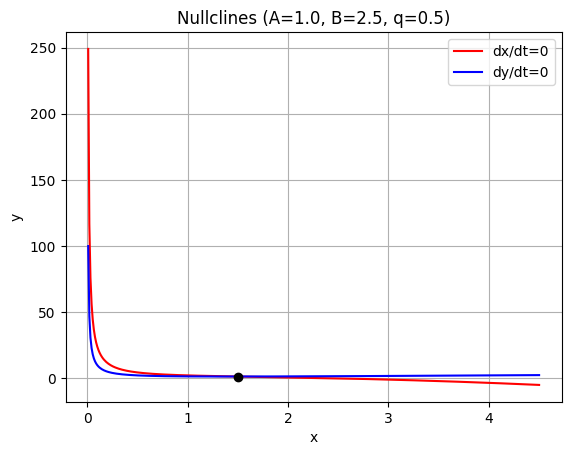

/var/folders/25/m49ymdvs1k9fzs7p330mzdph0000gn/T/ipykernel_2123/364769644.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  A_star = fsolve(eq, A0)[0]
/var/folders/25/m49ymdvs1k9fzs7p330mzdph0000gn/T/ipykernel_2123/364769644.py:11: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  A_star = fsolve(eq, A0)[0]


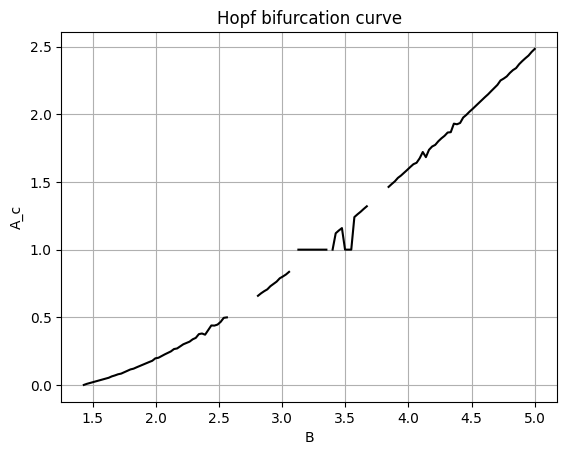

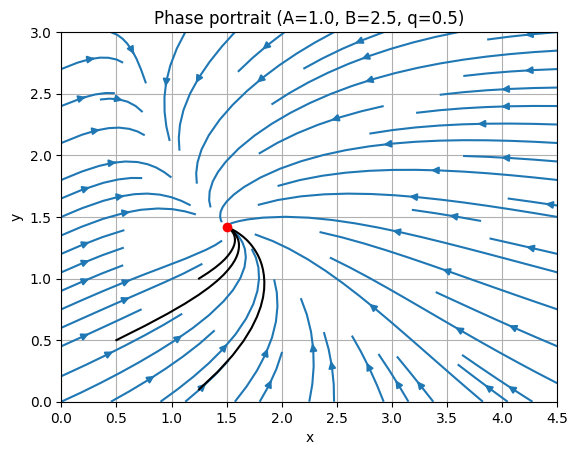

In [9]:
A, B, q = 1.0, 2.5, 0.5
fps = find_fp(A, B, q)
print('Fixed points:', fps)

for fp in fps:
    print(fp, classify(fp, A, B, q))

plot_null(A, B, q)
hopf_curve(q)
plot_phase(A, B, q)
